---
title: "Chapter 4, Part 1: Introduction to Forecasting"
subtitle: "Machine Learning"
date: "February 2026"
date-format: "MMMM YYYY"
author: 
  - F.San Segundo & N.Rodríguez
bibliography: ../exclude/mlmiin.bib
execute:
  echo: true
code-overflow: wrap
format: 
  html: 
    toc: true
    code-tools: true
    code-fold: show
    code-summary: "Hide the code"
    embed-resources: true
---

::: {.callout-warning icon=false}

##### Setting the working directory

We begin by using cd to make sure we are in the right folder.

:::

In [2]:
%cd exclude/MLMIINprv/fc26/4_1_Introduction_to_Forecasting/

/wd/exclude/MLMIINprv/fc26/4_1_Introduction_to_Forecasting


---

# Session Setup

::: {.callout-note  icon=false}

### Install additional libraries

We need to install some libraries from the [Nixtlaverse](https://nixtlaverse.nixtla.io/)

:::



In [3]:
import subprocess

def pip_install(package):
    result = subprocess.run(
        ["pip", "install", package],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        print(f"Error installing {package}: {result.stderr}")
    else:
        print(f"Successfully installed {package}")

pip_install("fpppy")
pip_install("tsfeatures")
pip_install("pyreadr")

::: {.callout-note  icon=false}

### Libraries

Let us also load the libraries we will use.

:::



In [4]:
# 1. System and Environment Setup
import os
import sys
import warnings
import random
import datetime
from tqdm import tqdm

# Set environment variables and ignore specific warnings
os.environ["NIXTLA_ID_AS_COL"] = "true"
warnings.filterwarnings(
    "ignore", 
    category=UserWarning, 
    message=".*FigureCanvasAgg is non-interactive.*"
)

# 2. Core Data Science Stack
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

# 3. Time Series & Machine Learning
import pmdarima as pmd
import yfinance as yf
import rdatasets
import pyreadr
from sktime.datasets import load_airline
from sktime.utils.plotting import plot_series as plot_series_sktime

# 4. Custom Utilities
from fc_4_1_utils.utils import *
from fpppy.utils import plot_series as plot_series_fpp
from utilsforecast.plotting import plot_series as plot_series_utils

# 5. Global Reproducibility & Display Settings
np.random.seed(1)
random.seed(1)
np.set_printoptions(suppress=True)

pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)

# 6. Plotting Configuration
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler

# Jupyter Magic
%matplotlib inline
%config InlineBackend.figure_format = 'png' # High-res plots

# Style and Aesthetics
plt.style.use("ggplot")
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

# Custom color cycle (Example: monochromatic black as per your original)
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])

---

#  General Concepts about Forecasting and Time Series

::: {.callout-note icon=false}

## Forecasting Terminology

A (basic **one-dimensional time series** (also called univariate time series) is, informally speaking, a set of data points (numbers) ordered in time:
$$
Y = \left\{y_1, y_2, \ldots, y_{t-1}, y_t,\ldots\right\}
$$


A **forecast** of the time series $Y$ is the prediction of some future event. Forecasting problems are classified as:

+ *Short-term:* a few time periods (days, weeks, months) into the future
+ *Medium-term:* from one to two years into the future
+ *Long-term:* many years

Short and medium term forecasting are tipically based on identifying, modeling and extrapolating the patterns found in historical data.  Long term forecasting is usually based on expert knowledge and fundamental models.


:::

![https://demanda.ree.es/visiona/peninsula/nacionalau/total/2025-3-16](./fig/ElectrictyDemandSpain.jpg){width=75% fig-align="center"}  
[Source:  Electricity demand tracking in real time, Red Eléctrica de España](https://demanda.ree.es/visiona/peninsula/nacionalau/total/2025-3-16)

# Examples of time series. Datetime operations with pandas.

::: {.callout-note icon=false}

## Time Series Examples Collection

After the preliminary code above is executed, the `data/fpppy` subfolder of the repository now contains a collection of frequently used time series examples. 

**Note:** this data files are ignored by git.

:::

::: {.callout-tip  icon=false}

### Exercise 001

Explore the folder: using a text editor open some of the csv files it contains and try to get a feeling of the typical structure of these examples.

:::

::: {.callout-note icon=false}

## Monthly Canadian gas production, billions of cubic metres, January 1960 - February 2005

The first example we will examine is this dataset that comes from the Rob Hyndman repository of time series at this link:

[Monthly Canadian gas production, billions of cubic metres, January 1960 - February 2005](http://pkg.robjhyndman.com/fpp3package/reference/canadian_gas.html)

The data is stored in a csv file like many we have used before, and we will read it as usual. We use `head`, `tail` and `info` to perform a first exploration.

:::

In [5]:
can_gas = pd.read_csv('canadian_gas.csv')

In [6]:
can_gas.head()

,Month,Volume
0,1960 Jan,1.431
1,1960 Feb,1.306
2,1960 Mar,1.402
3,1960 Apr,1.170
4,1960 May,1.116


In [7]:
can_gas.tail()

,Month,Volume
537,2004 Oct,17.827
538,2004 Nov,17.832
539,2004 Dec,19.453
540,2005 Jan,19.528
541,2005 Feb,16.944


In [8]:
can_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   542 non-null    object 
 1   Volume  542 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.6+ KB


::: {.callout-important icon=false}

### Temporal Ordering of the Rows

Pay special attention to the first column `Month`. In the datasets that we have used in Classification and Regression problems the ordering of the rows was not relevant. In fact, the observations were ucually assumed to be independent, and so permuting the rows did not affect the information in the dataset. But in a time series dataset like this, there is always a column (or columns) that describe a temporal ordering of the observations. The **row ordering is now an essential part of the dataset**. Ignoring this will ruin your analysis. 

:::

---

::: {.callout-note icon=false}

### Using `datetime` Type in Pandas

Because of this critical role of the time ordering, and also because of the complexity of the systems that we use to describe dates and time points, Pandas has a dedicated set of classes and methods to deal with temporal data. We will make an initial contact with the pandas `to_datetime` method and we will learn more about date and time operations as we go.

Our first step is to apply the method to the `Month`  column and run `info` again to see the resulting change in the column. For this first example we will first create a copy of the column called `date` to keep the original date format and use it as a reference:

:::

In [9]:
can_gas["Date"] = can_gas["Month"]

In [10]:
can_gas["Month"] = pd.to_datetime(can_gas["Month"], format="%Y %b")
can_gas.head()

,Month,Volume,Date
0,1960-01-01,1.431,1960 Jan
1,1960-02-01,1.306,1960 Feb
2,1960-03-01,1.402,1960 Mar
3,1960-04-01,1.170,1960 Apr
4,1960-05-01,1.116,1960 May


In [11]:
can_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Month   542 non-null    datetime64[ns]
 1   Volume  542 non-null    float64       
 2   Date    542 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 12.8+ KB


As you can see, pandas has transformed the column and has translated each date into the first day of the corresponding month. The type of the column is `datetime64[ns]`. This in particular means that we can perform operations such as the following. Note in particular that the results belong to two different classes, [`Timestamp`](https://pandas.pydata.org/docs/reference/api/pandas.Timestamp.html) (a point in time, an *instant*) and [`Timedelta`](https://pandas.pydata.org/docs/reference/api/pandas.Timedelta.html) (an interval in time, or *time span*):

In [12]:
can_gas["Month"].min(), can_gas["Month"].max(), can_gas["Month"][17] - can_gas["Month"][7]

(Timestamp('1960-01-01 00:00:00'),
 Timestamp('2005-02-01 00:00:00'),
 Timedelta('304 days 00:00:00'))

::: {.callout-note icon=false}

### The .dt accessor

The [`dt` accessor](https://pandas.pydata.org/pandas-docs/version/1.5/reference/api/pandas.Series.dt.html) allows us to extract temporal information in conveninent ways from a pandas temporal object. For example, suppose we want to add a column to `can_gas` that contains the year in which the observation was made. We can do it with `dt` followed by `year` as follows:

::: 

In [13]:
can_gas["Month"].dt.year

0      1960
1      1960
2      1960
3      1960
4      1960
       ... 
537    2004
538    2004
539    2004
540    2005
541    2005
Name: Month, Length: 542, dtype: int32

You can also use `dt` to get,for example, the quarter of the year, which is a frequently used measure in economical data:

In [14]:
can_gas["Month"].dt.quarter

0      1
1      1
2      1
3      2
4      2
      ..
537    4
538    4
539    4
540    1
541    1
Name: Month, Length: 542, dtype: int32

::: {.callout-note icon=false}

### Creating a Temporal Index

The temporal ordering of the data is so important that it is often used as the index of the dataframe, We can achieve this as follows:

::: 

In [15]:
can_gas.set_index('Month', drop=True, inplace=True)
# can_gas.set_index('Date', drop=True, inplace=True)
can_gas.head()


,Volume,Date
Month,,
1960-01-01,1.431,1960 Jan
1960-02-01,1.306,1960 Feb
1960-03-01,1.402,1960 Mar
1960-04-01,1.170,1960 Apr
1960-05-01,1.116,1960 May


::: {.callout-tip  icon=false}

### Exercise 002

What happens if you set `drop = False` here?

:::

::: {.callout-note icon=false}

### A First Time Series Plot

Usually we plot the time series with the temporal values ordered along the horizontal axis. We get this simply by calling plot. Note that the labels in the x axis (the so called *ticks*) are automatically selected in a temporal format. Take a look at the plot and look for remarkable patterns in it. 

**Note:** `sizets` and other parameters are defined in `utils.py` inside the `fc_4_1_utils` subfolder for this session, and imported above.

::: 

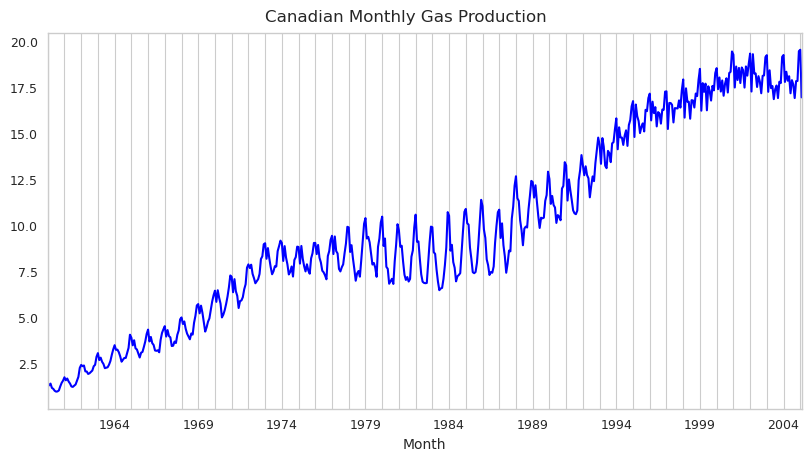

In [16]:
fig, ax = plt.subplots()
can_gas["Volume"].plot(figsize=sizets, c="blue", ax= ax)
fig.suptitle('Canadian Monthly Gas Production')
ax.grid(visible=True, which='Both', axis='x')
ax.grid(visible=False, which='Major', axis='y')
plt.show();plt.close()

::: {.callout-note icon=false}

## Yet another example: sea surface temperature data

The following time series is a monthly average of the global sea surface temperature anomaly from 1850 to 2020. From the website:

*"NOAAGlobalTemp combines the sea surface temperature (SST) with land surface air temperature (LSAT). Data is available as a series of temperature anomalies relative to a 1971–2000 monthly climatology. To compute anomalies relative to climatologies for other time periods (e.g. 1991–2020), calculate the average of the NOAAGlobalTemp anomalies for that time period (e.g. 1991–2020), and then subtract the average from the original anomalies."*

[NOAA Merged Land Ocean Global Surface Temperature Analysis (NOAAGlobalTemp)](https://www.ncei.noaa.gov/products/land-based-station/noaa-global-temp(avg).html)

:::


In [17]:
NOAA_global_temp = pd.read_csv("noaa.globaltmp.comb.csv", parse_dates=True, index_col=0, na_values=-9999.)
NOAA_global_temp

,NOAA Combined Land and Ocean Globally averaged Temperature missing value -999 https://psl.noaa.gov/data/timeseries/month/
Date,
1850-01-01,-0.775
1850-02-01,-0.551
1850-03-01,-0.566
1850-04-01,-0.679
1850-05-01,-0.609
...,...
2024-08-01,0.972
2024-09-01,0.964
2024-10-01,1.063


In [18]:
NOAA_global_temp.columns = ['Temp_Anomaly'] 
NOAA_global_temp

,Temp_Anomaly
Date,
1850-01-01,-0.775
1850-02-01,-0.551
1850-03-01,-0.566
1850-04-01,-0.679
1850-05-01,-0.609
...,...
2024-08-01,0.972
2024-09-01,0.964
2024-10-01,1.063


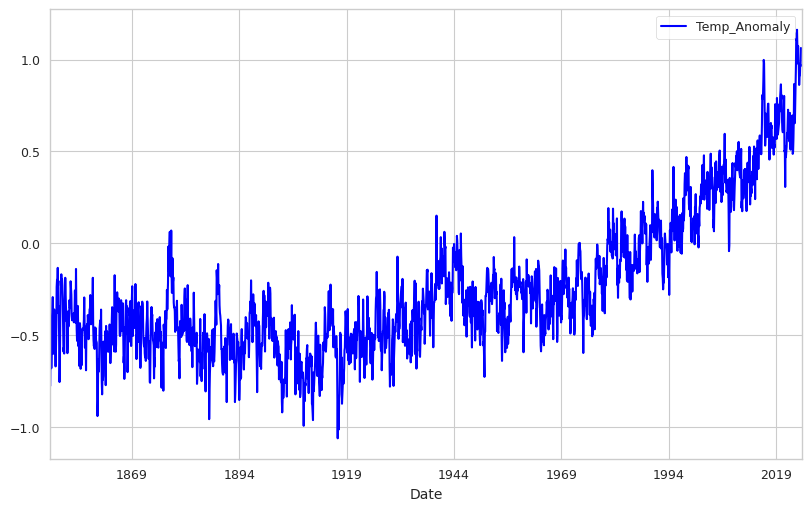

In [19]:
NOAA_global_temp.plot(color="blue")
plt.show();plt.close()  

::: {.callout-note icon=false}

## A multi-series example

The following example shows that a dataset can consist of several time series sharing the same time interval and sampling rate. In this case the data in [aus_production](https://tsibbledata.tidyverts.org/reference/aus_production.html) (also from Hyndman and his collaborators) describes the quarterly production volume of several australian industries from 1956 to approximately 2010 (the time series are not all equally long). 

:::


In [20]:
aus_production = pd.read_csv("aus_production.csv")
aus_production.head()

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956 Q1,284,5225.0,189.0,465,3923,5
1,1956 Q2,213,5178.0,204.0,532,4436,6
2,1956 Q3,227,5297.0,208.0,561,4806,7
3,1956 Q4,308,5681.0,197.0,570,4418,6
4,1957 Q1,262,5577.0,187.0,529,4339,5


This time the data is quarterly, but with a time index that contains spaces. This is often not well parsed by pandas so we first use string management functions  to remove the blank space in `Quarter`.

In [21]:
aus_production['Quarter'] = aus_production['Quarter'].str.replace(" ", "", regex=False)
aus_production.head()

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956Q1,284,5225.0,189.0,465,3923,5
1,1956Q2,213,5178.0,204.0,532,4436,6
2,1956Q3,227,5297.0,208.0,561,4806,7
3,1956Q4,308,5681.0,197.0,570,4418,6
4,1957Q1,262,5577.0,187.0,529,4339,5


The problem now is that (rather surprisingly) the [`strptime` method used by pandas](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior) does not have a notion of quarters.  
**Note:** we strongly recommend that you check the codes used to represent dates and times.

If we try a direct conversion without specifying the format, we get a warning that, nstead of its default `strptime`, pandas is switching to a more general parser [`dateutil`](https://dateutil.readthedocs.io/en/stable/). And as you can see below the quarter is represented by its first day, because datetime objects conceptually describe *instants* in time. 

In [22]:
aus_production['Quarter'] = pd.to_datetime(aus_production['Quarter'])
aus_production.head()

/tmp/ipykernel_10/3424000628.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  aus_production['Quarter'] = pd.to_datetime(aus_production['Quarter'])


,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956-01-01,284,5225.0,189.0,465,3923,5
1,1956-04-01,213,5178.0,204.0,532,4436,6
2,1956-07-01,227,5297.0,208.0,561,4806,7
3,1956-10-01,308,5681.0,197.0,570,4418,6
4,1957-01-01,262,5577.0,187.0,529,4339,5


We can now proceed to set `Quarter` as the index. Note its type in the output of `info`:

In [23]:
aus_production.set_index('Quarter', drop=True, inplace=True)
aus_production.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 218 entries, 1956-01-01 to 2010-04-01
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Beer         218 non-null    int64  
 1   Tobacco      194 non-null    float64
 2   Bricks       198 non-null    float64
 3   Cement       218 non-null    int64  
 4   Electricity  218 non-null    int64  
 5   Gas          218 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 11.9 KB


An alternative to this (after setting the index!) is to convert the index `Quarter` to a different kind of time data structure, a [`PeriodIndex`](https://pandas.pydata.org/docs/reference/api/pandas.PeriodIndex.html) specifically designed to represent periods of time. 

In [24]:
aus_production = aus_production.to_period(freq="Q")
aus_production.head()

,Beer,Tobacco,Bricks,Cement,Electricity,Gas
Quarter,,,,,,
1956Q1,284,5225.0,189.0,465,3923,5
1956Q2,213,5178.0,204.0,532,4436,6
1956Q3,227,5297.0,208.0,561,4806,7
1956Q4,308,5681.0,197.0,570,4418,6
1957Q1,262,5577.0,187.0,529,4339,5


Note that the index is now a `PeriodIndex` as expected.

In [25]:
aus_production.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 218 entries, 1956Q1 to 2010Q2
Freq: Q-DEC
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Beer         218 non-null    int64  
 1   Tobacco      194 non-null    float64
 2   Bricks       198 non-null    float64
 3   Cement       218 non-null    int64  
 4   Electricity  218 non-null    int64  
 5   Gas          218 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 11.9 KB


Finally let us plot the dataset in panels so that each time series in the dataset gets its own vertical axis:

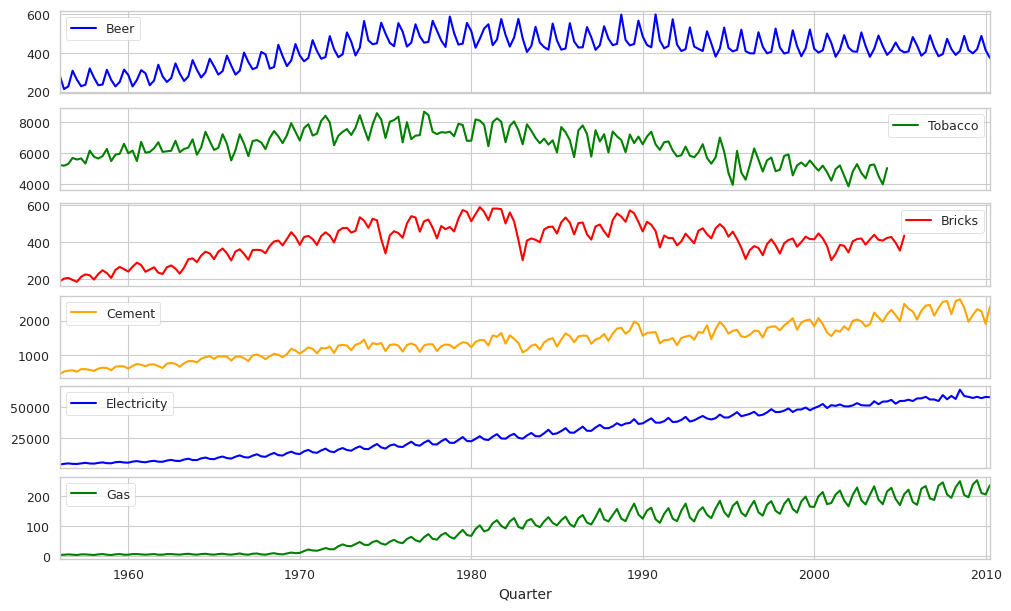

In [26]:
aus_production.plot(
        subplots=True,
        layout=(aus_production.shape[1], 1),
        sharex=True,
        figsize=(10, 6),
        legend=True,
        color=["blue", "green", "red", "orange"]
    )
plt.show();plt.close()  

::: {.callout-note icon=false}

## Another example: finantial data from Yahoo Finance

Finantial data are a frequent example of time series applications. We will use the `yfinance` library to download the daily prices of a couple of stocks, using the tech companies `Apple` (ticker `AAPL`) and Microsoft (ticker `MSFT`) to download the closing prices of the last 10 (520 weeks) years at the NYSE.

:::

In [27]:
jj = pd.read_csv('jj.csv')
jj.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


The index is again quarterly, but the date column is not in a regular datetime format (observe e.g. the third row). Let us convert it and set it as the index.

In [28]:
jj.date = pd.to_datetime(jj.date)
jj.set_index('date', drop=True, inplace=True)
jj.index = jj.index.to_period('Q')
jj.head()

,data
date,
1960Q1,0.71
1960Q2,0.63
1960Q3,0.85
1960Q4,0.44
1961Q1,0.61


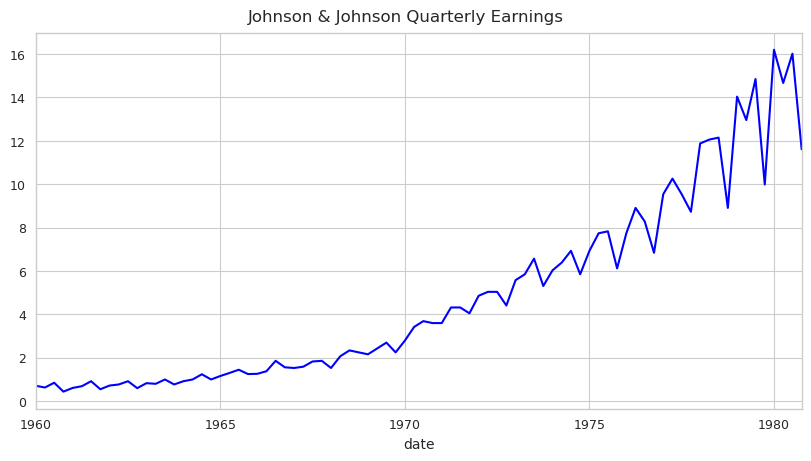

In [29]:
# Plotting the quarterly Johnson & Johnson earnings data
fig, ax = plt.subplots()
jj["data"].plot(figsize=sizets, c="blue", ax=ax)
fig.suptitle('Johnson & Johnson Quarterly Earnings')
plt.show();plt.close()

# Data wrangling specific issues with time series data

::: {.callout-note icon=false}

## A more complicated example: unemployment in Spain

This dataset contains data about unemployment in Spain from 2010 to 2022. The data is again stored in a csv file like many we have used before, and we will read it with pd.read_csv as usual.  But this time we are using the `parse_dates` argument of `read_csv` to directly try to transform the `DATE` column into a datetime object.

:::

In [30]:
unemployment = pd.read_csv('unemployment.csv', index_col="DATE", parse_dates=True)

We use `head`, `tail` and `info` to perform a first exploration. At first sight it may apear to be correct. 

In [31]:
unemployment.head()

,TOTAL
DATE,
2010-01-01,4048493
2010-01-02,4130625
2010-01-03,4166613
2010-01-04,4142425
2010-01-05,4066202


In [32]:
unemployment.tail()

,TOTAL
DATE,
2022-01-08,2924240
2022-01-09,2941919
2022-01-10,2914892
2022-01-11,2881380
2022-01-12,2837653


In [33]:
unemployment.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 157 entries, 2010-01-01 to 2022-01-12
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0    TOTAL  157 non-null    object
dtypes: object(1)
memory usage: 2.5+ KB


But the `info` method reveals that **there is something off with the data.** 
+ the column `TOTAL` is of type `object`, and not a float. 
+ there are only 157 entries (rows), and if the data is daily (as you may have thought), there should be a much larger number of rows.

Let us ask for a bigger number of rows with `head(15)` to see if we can spot the problem.


In [34]:
unemployment.head(15)

,TOTAL
DATE,
2010-01-01,4048493
2010-01-02,4130625
2010-01-03,4166613
2010-01-04,4142425
2010-01-05,4066202
2010-01-06,3982368
2010-01-07,3908578
2010-01-08,3969661
2010-01-09,4017763


The problem is, of course, that **the data is not daily, but monthly**. We can see that the `DATE` column is in the format `YYYY-01-MM`, and that the `TOTAL` column is the number of unemployed people in Spain in that month. We are simply given the number of unemployed people in Spain in the first day of each month. The ambiguity of the date is due to the fact that sometimes 2020-03-01 is used to refer to the first day of March 2020 (as in the [ISO 8601 standard](https://en.wikipedia.org/wiki/ISO_8601)), and sometimes it refers to the third day of January 2020 (this is the common use e.g. the in US). Sometimes you will realize this right away, But quite often mistakes like this can go unnoticed until they pop up in the middle of your analysis (if you are lucky).

::: {.callout-important  icon=false}

### Pay attention to the temporal resolution of the data!

We usually work with time series that have been sampled at a certain fixed frequency. This frequency is usually daily, weekly, monthly, quarterly, or yearly. Sometimes subdaily frequencies are used: sampling by hours, minutes, seconds, etc. It is **critical to know the frequency of the data**, because it will determine much of the subsequent analysis.

Take your time to do exploratory data analysis and gather information about the data frequency before proceeding with the analysis.

:::

The best way out of the situation is to read the data again with a different day format specification. We recommend **always look at your text data files using a text editor first.**

In [35]:
unemployment = pd.read_csv('unemployment.csv')
unemployment["DATE"] = pd.to_datetime(unemployment["DATE"], format="%d/%m/%Y")
unemployment.set_index("DATE", inplace=True)
unemployment.head(15)

,TOTAL
DATE,
2010-01-01,4048493
2010-02-01,4130625
2010-03-01,4166613
2010-04-01,4142425
2010-05-01,4066202
2010-06-01,3982368
2010-07-01,3908578
2010-08-01,3969661
2010-09-01,4017763


Notice however that this is not the end of our problems. The info method still shows the `TOTAL` column as an object. 

In [36]:
unemployment.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 157 entries, 2010-01-01 to 2022-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0    TOTAL  157 non-null    object
dtypes: object(1)
memory usage: 2.5+ KB


This is often a symptom of the pressence of undetected missing values. Can we check this with the `isna` method?

In [37]:
unemployment.isna().sum()   

TOTAL    0
dtype: int64

That did not work. The `isna` method is not detecting the missing values. What if we bluntly try to convert the column to a float? Uncomment and run the following cell:

In [38]:
# unemployment["TOTAL"] = unemployment["TOTAL"].astype(float)

The error we get reveals that the problem is in the delimiter used in the csv file. We assumed it was a comma, but it is actually a comma plus a space. We can fix this by using the `delimiter` argument of `read_csv`:

In [39]:
unemployment = pd.read_csv('unemployment.csv', delimiter=", ")
unemployment["DATE"] = pd.to_datetime(unemployment["DATE"], format="%d/%m/%Y")
unemployment.set_index("DATE", inplace=True)
unemployment.head()

/tmp/ipykernel_10/536289778.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  unemployment = pd.read_csv('unemployment.csv', delimiter=", ")


,TOTAL
DATE,
2010-01-01,4.048e+06
2010-02-01,4.131e+06
2010-03-01,4.167e+06
2010-04-01,4.142e+06
2010-05-01,4.066e+06


This looks much better (note the decimal point in the `TOTAL` column). Let us check it with `info` again:

In [40]:
unemployment.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 157 entries, 2010-01-01 to 2022-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TOTAL   156 non-null    float64
dtypes: float64(1)
memory usage: 2.5 KB


There seems to be a missing value in the `TOTAL` column. We can check this with the `isna` method:

In [41]:
unemployment.isna().sum()  

TOTAL    1
dtype: int64

And now we identify the missing value.

In [42]:
unemployment[unemployment['TOTAL'].isna()]

,TOTAL
DATE,
2013-01-01,NaN


::: {.callout-warning icon=false}

### Silent missing values: time gaps in the data

The following issue we are going to address is a particular problem with time series data. As we have said, the temporal structure of the data is essential. This means that the absence of a data point at a certain time is a piece of information in itself. We call this a **time gap** in the series and it can easily go unnoticed at first sight. But such time gaps can cause problems in the analysis downstream, as some models will simply be unable to handle them. It is important to get in the habit of detecting time gaps and dealing with them.

:::

We can do that by first creating a sequence of time instants with the same frequency as our time series but without time gaps. We call it a **full range** below. We do this using the pandas function [`date_range`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.date_range.html). 

We then simply compare that sequence with the index of the time series:

In [43]:
# Find start and end date of the rime series
start_date = unemployment.index.min()
end_date = unemployment.index.max()
print(start_date, end_date)

# Generate a full range of months
full_range = pd.date_range(start=start_date, end=end_date, freq='MS')  # 'MS' ensures month start
full_range[:5], full_range[-5:]

2010-01-01 00:00:00 2022-12-01 00:00:00


(DatetimeIndex(['2010-01-01', '2010-02-01', '2010-03-01', '2010-04-01',
                '2010-05-01'],
               dtype='datetime64[ns]', freq='MS'),
 DatetimeIndex(['2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01',
                '2022-12-01'],
               dtype='datetime64[ns]', freq='MS'))

These are the missing months:

In [44]:
missing_months = full_range.difference(unemployment.index)
missing_months

DatetimeIndex(['2015-04-01'], dtype='datetime64[ns]', freq='MS')

In order to fill the gaps we will create a new dataset with a complete list of years. We can do that with the following code. Uncomment and run the following cell:

In [45]:
# unemployment = unemployment.reindex(full_range)

But if you do you will get an error about our index having *duplicate labels*. That is, some dates are duplicated.

::: {.callout-warning icon=false}

### Duplicated rows

Duplicated rows in the data files are always problematic in data analysis. Machine Learning models like the ones we have been working with until now are however often able to handle them. That is not to say that they are not a problem: a duplicated row is a piece of information that is repeated, and this can lead to biases in the analysis.

But **in time series data, duplicated rows are a much more serious problem**. The temporal structure of the data is essential, and duplicated rows can ruin it. 


:::

Let us try to detect the duplicated rows with the pandas [`duplicated`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.duplicated.html) method. Read the documentation to understand what `keep` means. In order to do the simplest way is to read the data again and check for duplicates *before* making the date column into the index. 

In [46]:
unemployment = pd.read_csv('unemployment.csv', delimiter=", ")
unemployment["DATE"] = pd.to_datetime(unemployment["DATE"], format="%d/%m/%Y")

/tmp/ipykernel_10/1481882061.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  unemployment = pd.read_csv('unemployment.csv', delimiter=", ")


In [47]:
unemployment[unemployment["DATE"].duplicated(keep=False)]


,DATE,TOTAL
141,2021-11-01,3.183e+06
142,2021-11-01,3.183e+06
148,2022-05-01,2.923e+06
149,2022-05-01,2.923e+06


Those are the duplicated rows and we can see that the whole row is truly duplicated. We can therefore remove them without losing information. In more complex situations we would need to consider the reason why the rows are duplicated and how to handle them.

Here we can simply remove them with the `drop_duplicates` method. Again, check the use of `keep` here: we do not want to remove all the duplicates, only the second appearance of each duplicated row.

In [48]:
unemployment = unemployment.drop_duplicates(subset="DATE", keep='first')

Now we are ready to set the temporal index again:

In [49]:
unemployment.set_index("DATE", inplace=True)
unemployment.head()

,TOTAL
DATE,
2010-01-01,4.048e+06
2010-02-01,4.131e+06
2010-03-01,4.167e+06
2010-04-01,4.142e+06
2010-05-01,4.066e+06


Recall that we need to add the index values for the time gaps.

In [50]:
full_range.difference(unemployment.index)

DatetimeIndex(['2015-04-01'], dtype='datetime64[ns]', freq='MS')

In [51]:
unemployment = unemployment.reindex(full_range)

In [52]:
full_range.difference(unemployment.index)

DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

After doing all this we check the state of the data with `head`. Note a side effect of reindexing: the name for the index column is lost. 

In [53]:
unemployment.head()

,TOTAL
2010-01-01,4.048e+06
2010-02-01,4.131e+06
2010-03-01,4.167e+06
2010-04-01,4.142e+06
2010-05-01,4.066e+06


We fix the name.

In [54]:
unemployment.index.name = 'DATE'
unemployment.head()

,TOTAL
DATE,
2010-01-01,4.048e+06
2010-02-01,4.131e+06
2010-03-01,4.167e+06
2010-04-01,4.142e+06
2010-05-01,4.066e+06


And use `info` to check the state of the data:

In [55]:
unemployment.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 156 entries, 2010-01-01 to 2022-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TOTAL   154 non-null    float64
dtypes: float64(1)
memory usage: 6.5 KB


We can now circle back to the missing values in the `TOTAL` column. 

In [56]:
unemployment.isna().sum()

TOTAL    2
dtype: int64

You may recall that previously we had found one missing data row in `TOTAL`. How come there are two missing values now? The answer is that the new missing value is due to the time gap we have just filled. We can check this to be the case. Look above for the dates of the original missing data and the time gap:

In [57]:
missing_dates = unemployment[unemployment['TOTAL'].isna()]
missing_dates


,TOTAL
DATE,
2013-01-01,NaN
2015-04-01,NaN


::: {.callout-note icon=false}

## Filling the gaps


When our time series contains missing values (not time gaps!) we have several options to fill them, using **imputation** techniques. The simplest is to fill them with a constant value. We could do this with the pandas [`fillna`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html) method. Read the pandas documentation. You can also check this [Medium post: Data Imputation Demystified | Time Series Data ](https://medium.com/@aaabulkhair/data-imputation-demystified-time-series-data-69bc9c798cb7)

Here however we will use linear interpolation, because it seems to do a better job at preserving the temporal behavior of the data. We can do this with the pandas [`interpolate`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.interpolate.html) method. Read the pandas documentation!

First we plot a zoomed in section of the time series around one of the two missing values to see the effect of the interpolation:

:::

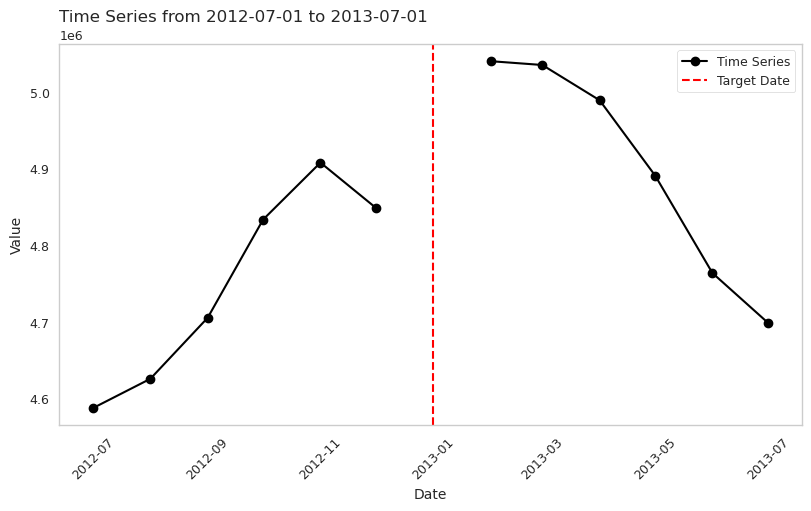

In [58]:
target_date = missing_dates.index[0]

start_date = target_date - pd.DateOffset(months=6)
end_date = target_date + pd.DateOffset(months=6)

# Select data in this range
unemployment_selected = unemployment.loc[start_date:end_date]

# Plot the selected time series
plt.figure(figsize=(8, 5))
plt.plot(unemployment_selected.index, unemployment_selected['TOTAL'], marker='o', linestyle='-', label="Time Series")
plt.axvline(target_date, color='red', linestyle='--', label="Target Date")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"Time Series from {start_date.date()} to {end_date.date()}")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()

Now we fill the missing values with linear interpolation and replot that section of the time series:

In [59]:
unemployment["TOTAL"] = unemployment["TOTAL"].interpolate(method="linear")

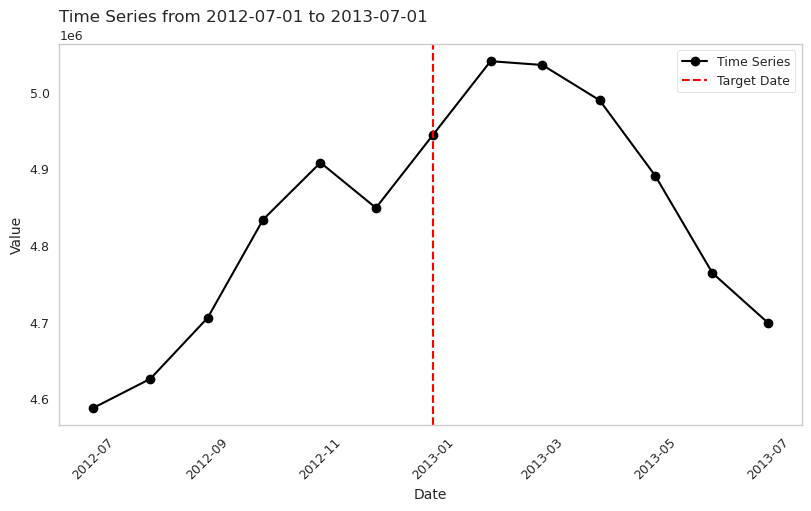

In [60]:
target_date = missing_dates.index[0]

start_date = target_date - pd.DateOffset(months=6)
end_date = target_date + pd.DateOffset(months=6)

# Select data in this range
unemployment_selected = unemployment.loc[start_date:end_date]

# Plot the selected time series
plt.figure(figsize=(8, 5))
plt.plot(unemployment_selected.index, unemployment_selected['TOTAL'], marker='o', linestyle='-', label="Time Series")
plt.axvline(target_date, color='red', linestyle='--', label="Target Date")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"Time Series from {start_date.date()} to {end_date.date()}")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()

We can now check that there are no remaining missing values:

In [61]:
unemployment.isna().sum()

TOTAL    0
dtype: int64

And plot the whole time series:

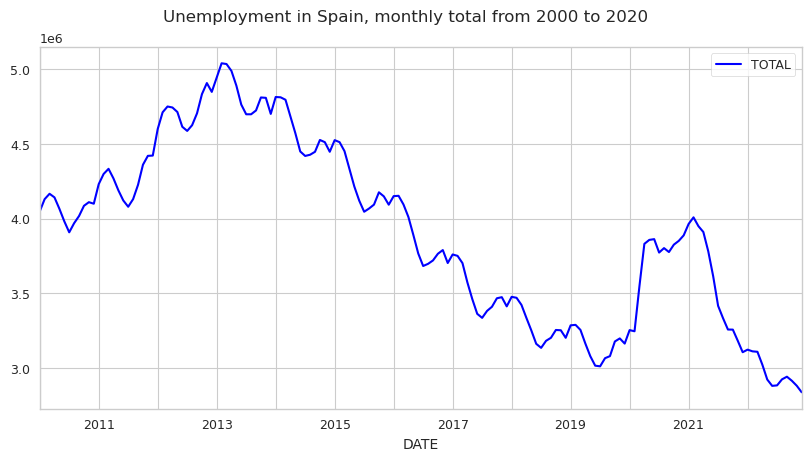

In [62]:
fig, ax = plt.subplots()
unemployment.plot(figsize=sizets, c="blue", ax= ax)
fig.suptitle('Unemployment in Spain, monthly total from 2000 to 2020')
ax.grid(visible=True, which='Both', axis='x')
plt.show();plt.close()

# The nixtla format for time series data

::: {.callout-note icon=false}

#### A format for recent models

Facebook published and open-sourced the *Prophet* forecasting model in early 2017. It quickly became extremely popular in business analytics, due to its ease of use by non-experts, compared with classical models such as those in the Arima family.  We will learn about Prophet later in the course, but the reason we are bringing it up now is because it started a naming convention that has now become a de facto standard for many forecsting libraries, including those in the *Nixtlaverse*. In Prophet, to simplify the user experience, the developers enforced a strict input format in time series data:

+ `ds`: stands for *datestamp*. It should be a column of dates or timestamps (specifically YYYY-MM-DD or YYYY-MM-DD HH:MM:SS).
+ `y`: represents the numeric value to be forecasted (we will often refer to it as the *output* in a slight abuse of language).+
+ Another column called `unique_id` is used to identify each individual series when there are several time series in the same dataset. In such cases the different series are not separated in columns but rather by this identifier column. 

:::

::: {.callout-note  icon=false}

### Download and extract data for the examples

The data comes from the *fpppy book* by Hyndman, Athanasopoulos et al. (see the [*recommended readings* in our course website](https://ml-mic.github.io/MLMIIN_public/#forecasting)). Let us download it and store it permanently in our disk. It will be stored in a folder called `data` in the MLMIIN repo folder (and it will be ignored by git); if the `data` folder already exists don't worry, it will not be overwritten.

:::



In [63]:
!mkdir -p /wd/data

In [64]:
# %cd /wd/data
!wget -nc -P /wd/data https://otexts.com/fpppy/data/fpppy_data.zip


File ‘/wd/data/fpppy_data.zip’ already there; not retrieving.



In [65]:
import zipfile

fpppy_path = '/wd/data/fpppy/'

# Extract the zip file
with zipfile.ZipFile('/wd/data/fpppy_data.zip', 'r') as zip_ref:
    
    zip_ref.extractall(path=fpppy_path)
    !cp -r /wd/data/fpppy/data/* /wd/data/fpppy
    !rm -rf /wd/data/fpppy/data

Let us see the canadian gas data example in this format:

In [66]:
can_gas_nx = pd.read_csv(fpppy_path + '/canadian_gas.csv', parse_dates=['ds'])
can_gas_nx.head()

,unique_id,ds,y
0,Canadian gas production,1960-01-01,1.431
1,Canadian gas production,1960-02-01,1.306
2,Canadian gas production,1960-03-01,1.402
3,Canadian gas production,1960-04-01,1.170
4,Canadian gas production,1960-05-01,1.116


Now we can plot the time series with a function provided by the fpppy package (we imported it as `plot_series_fpp` to distinguish it from similarly called functions in other libraries).

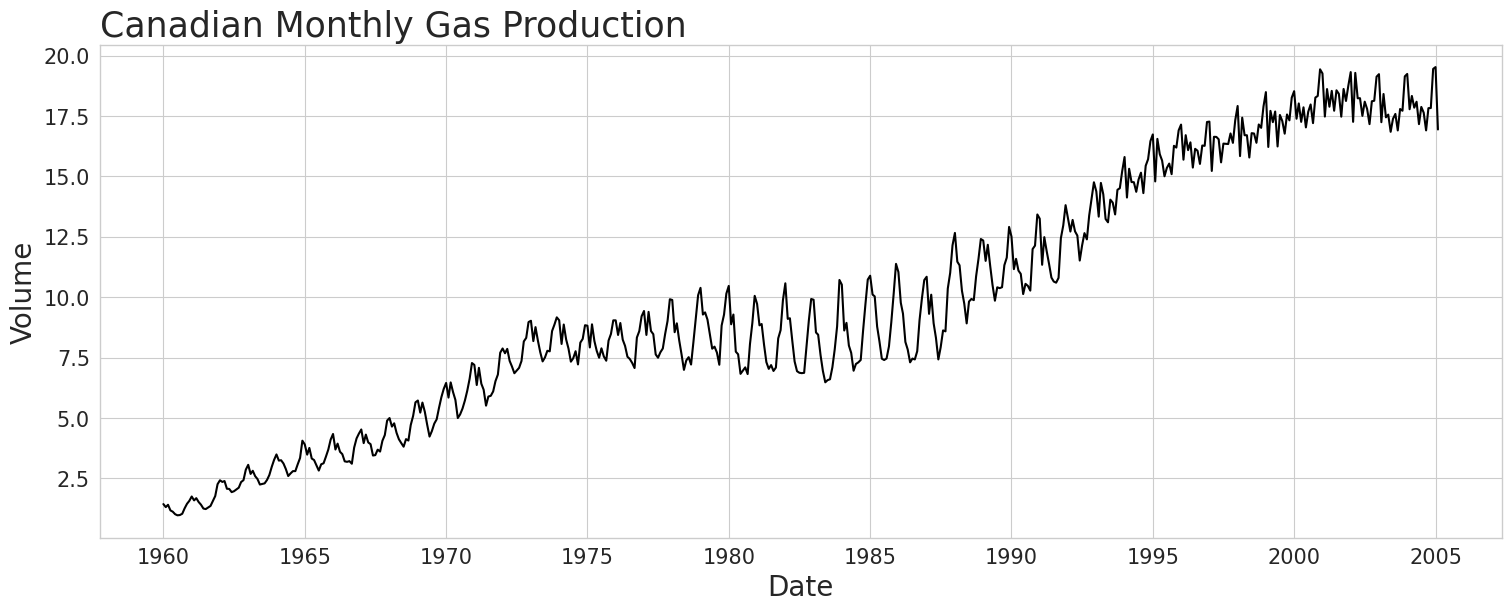

In [67]:
plot_series_fpp(can_gas_nx, title="Canadian Monthly Gas Production", xlabel="Date", ylabel="Volume")

::: {.callout-warning icon=false}

#### Switching to this notation

In this part of the course we intend to follow closely the discussion in Hyndman's book. Therefore we will preferably use the ds, y notational convention for dealing with time series. 

:::

Let us in fact apply this to use a single name for our canadian gas example.

In [68]:
# can_gas = can_gas_nx

::: {.callout-note icon=false}

#### Switching to this notation


If you need to convert a time series to this format pandas provides a `rename` method that deals with columns and a accessor properties for the index.. 

:::

Let us try this with the unemployment time series example. First recall the series structure:

In [69]:
unemployment.head()

,TOTAL
DATE,
2010-01-01,4.048e+06
2010-02-01,4.131e+06
2010-03-01,4.167e+06
2010-04-01,4.142e+06
2010-05-01,4.066e+06


Now we rename it and examine the result:

In [70]:
unemployment = unemployment.rename(columns={'TOTAL': 'y'})
unemployment.index.name = 'ds'
unemployment.head()

,y
ds,
2010-01-01,4.048e+06
2010-02-01,4.131e+06
2010-03-01,4.167e+06
2010-04-01,4.142e+06
2010-05-01,4.066e+06


## Other examples of data wrangling operations


::: {.callout-note icon=false}

## Working with dataframes

The examples that we are going to see in this section are not specific for time series datasets. They involve common operations with tabular data, such as row-wise and column-wise selection, grouping, aggregating, etc. They are therefore, as we just said, not limited to Forecasting or even Machine Learning, they are rather foundational tools for any project involving data. We ~~urge~~ invite  you to begin reading [Group by: split-apply-combine](https://pandas.pydata.org/docs/dev/user_guide/groupby.html#transformation) in the scikit documentation - it is a long read!

:::

We will use another example from Hyndman's book. The PBS dataset containing sales data on pharmaceutical products in Australia (more info on the [Fpp3 book's website](https://otexts.com/fpp3/case-studies.html#case-2)). 

In [71]:
PBS = pd.read_csv(fpppy_path + 'pbs.csv', parse_dates=['Month'])
PBS.head()


/tmp/ipykernel_10/581389407.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  PBS = pd.read_csv(fpppy_path + 'pbs.csv', parse_dates=['Month'])


,Unnamed: 0,Month,Concession,Type,ATC1,ATC1_desc,ATC2,ATC2_desc,Scripts,Cost
0,1,1991-07-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,18228,67877.0
1,2,1991-08-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,15327,57011.0
2,3,1991-09-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,14775,55020.0
3,4,1991-10-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,15380,57222.0
4,5,1991-11-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A01,STOMATOLOGICAL PREPARATIONS,14371,52120.0


The next code examples are inspired by [Section 2.1 of (@hyndman2025fpppy)](https://otexts.com/fpppy/nbs/02-graphics.html#sec-DataFrame). We are going to create a pandas data pipe (similar to the scikit pipes). Now we apply query to do a row-wise selection, we want to extract those rows corresponding to an antidiabetic drug named `A10`. 

In [72]:
PBS.query('ATC2 == "A10"')

,Unnamed: 0,Month,Concession,Type,ATC1,ATC1_desc,ATC2,ATC2_desc,Scripts,Cost
1524,1525,1991-07-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,89733,2.093e+06
1525,1526,1991-08-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,77101,1.796e+06
1526,1527,1991-09-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,76255,1.777e+06
1527,1528,1991-10-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,78681,1.849e+06
1528,1529,1991-11-01,Concessional,Co-payments,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,70554,1.686e+06
...,...,...,...,...,...,...,...,...,...,...
52339,52340,2008-02-01,General,Safety net,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,10869,5.307e+05
52340,52341,2008-03-01,General,Safety net,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,1119,5.177e+04
52341,52342,2008-04-01,General,Safety net,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,721,3.629e+04
52342,52343,2008-05-01,General,Safety net,A,Alimentary tract and metabolism,A10,ANTIDIABETIC THERAPY,1947,1.012e+05


Now we do column-wise selection to keep only the months and costs. Our data pipe is becoming more complex, so we surround it with parenthesis to increase readability, putting each step in a separate line.

In [73]:
(PBS
 .query('ATC2 == "A10"')
 .filter(items=['Month', 'Cost'])
)


,Month,Cost
1524,1991-07-01,2.093e+06
1525,1991-08-01,1.796e+06
1526,1991-09-01,1.777e+06
1527,1991-10-01,1.849e+06
1528,1991-11-01,1.686e+06
...,...,...
52339,2008-02-01,5.307e+05
52340,2008-03-01,5.177e+04
52341,2008-04-01,3.629e+04
52342,2008-05-01,1.012e+05


The next pipe step is really a two step process: 

+ First we group the data by months using `groupby`. The output of this is a *grouped dataframe*. Refer to the [scikit documentation](https://pandas.pydata.org/docs/dev/user_guide/groupby.html#grouping-dataframe-with-index-levels-and-columns) if/when you want/need to learn more about these objects. 
+ Then we use `agg`  (short for *aggregate*) and a lambda function that gets the sum of the `Cost` column (the only one remaining after grouping) and converts it to millions (AUS$). 

In [74]:
(PBS
 .query('ATC2 == "A10"')
 .filter(items=['Month', 'Cost'])
 .groupby('Month', sort=False)
 .agg(lambda x: x.sum() / 1e6)
)




,Cost
Month,
1991-07-01,3.527
1991-08-01,3.181
1991-09-01,3.252
1991-10-01,3.611
1991-11-01,3.566
...,...
2008-02-01,21.654
2008-03-01,18.265
2008-04-01,23.108


::: {.callout-tip  icon=false}

### Exercise 003

Keep reading scikit documentation and learn how to change this pipe so that the output contains two columns, the first one is what we already have (the monthly sum of costs in millions) but the second one contains the total number of scripts that give rise to that cost, 

:::

In [75]:
# (PBS
#  .query('ATC2 == "A10"')
#  .filter(items=['Month', 'Cost', 'Scripts'])
#  .groupby('Month', sort=False)
#  .agg({'Cost': lambda x: x.sum() / 1e6, 'Scripts': lambda x: x.sum()})   
# )

In the final part we are going to apply the ds/y naming convention we have discussed. But to do that in this pipe setting we modify the procedure slightly. The reason is that we want to be able to modify the name of the month, that has now become the index. Thus, we rest the index (make it a regular column again), rename and set the index again.  We store this as the final result of the pipe giving it a name.

In [76]:
a10 = (PBS
 .query('ATC2 == "A10"')
 .filter(items=['Month', 'Cost'])
 .groupby('Month', sort=False)
 .agg(lambda x: x.sum() / 1e6)
 .reset_index()
 .rename(columns={'Cost': 'y', 'Month': 'ds'})
 .set_index('ds', drop=True)
 )

a10.head(10)

,y
ds,
1991-07-01,3.527
1991-08-01,3.181
1991-09-01,3.252
1991-10-01,3.611
1991-11-01,3.566
1991-12-01,4.306
1992-01-01,5.088
1992-02-01,2.815
1992-03-01,2.986


Now the aggregated time series is ready for any downstream process, modeling, etc. Let us e.g. make a time plot for EDA.

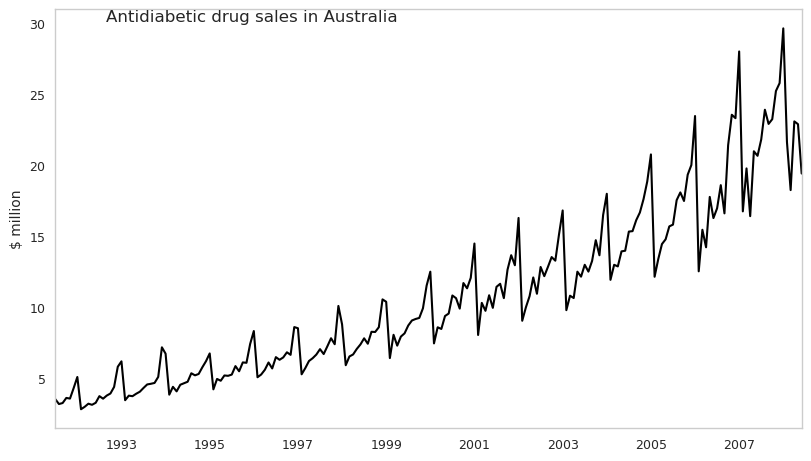

In [77]:
ax = a10["y"].plot(figsize=sizets)
suptitle('Antidiabetic drug sales in Australia')
ax.set(ylabel='$ million', xlabel='')
ax.grid()
plt.show();plt.close()

___

# Time Series Components. Trend and Seasonality.

::: {.callout-note icon=false}

#### Temporal Patterns in Time Series.


If you look at the time series examples above it is hard to miss that they exhibit certain kind of patterns as they evolve through time. 



**Trend.** Some of the time series plots in the previous examples show a general *upward* or *downward* direction when you consider the series as a whole over long periods of time.  A trend is therefore a long term increase or decrease of the time series values. That is not to say that the time series is always increasing or decreasing. 

**Seasonality.** Many time series take values that are affected by periodic phenomena such as the change of seasons as the Earth circles the Sun, the day/night cycle or the weekend vs workdays common in many human activities. These cyclical or periodic behavior is often easy to spot in the time plot of the series in the presence of an underlying pattern that repeats with a fixed frequency (hourly, daily or weekly and so on). Keep in mind however that the time series we are interested in  are not deterministic. They are affected by noise terms and so these repeating patterns are not exact copies (as would be the case in a purely periodic time series in the mathematical sense). 

:::

::: {.callout-tip  icon=false}

### Exercise 003

+ Let us look back at the canadian gas example. Can you see trend and seasonality at play here?
+ Look at the time series in [Figure 2.3 of [@hyndman2025fpppy]](https://otexts.com/fpppy/nbs/02-graphics_files/figure-html/fourexamples-output-1.png) and answer if they have a visible trend or they display seasonal behavior.

:::

___

::: {.callout-note icon=false}

#### Estimating the Trend

How can we estimate the trend of a time series? A trend in a series such as the canadian gas production means for example that the average value for the late 90s is higher than it was in the 60s. Therefore to investigate the trend we can think about **local means**. Not the total average of the time series, but a **rolling window** average that only takes into account the most recent years. 

In Python we can get this kind of *windowed measures* with `rolling` followed by the function we want to aplly. In this case, the mean.

:::

We return to the canadian gas example.

In [78]:
can_gas.head()

,Volume,Date
Month,,
1960-01-01,1.431,1960 Jan
1960-02-01,1.306,1960 Feb
1960-03-01,1.402,1960 Mar
1960-04-01,1.170,1960 Apr
1960-05-01,1.116,1960 May


In [79]:
window_size = 24
can_gas["mean_window_k"] = can_gas["Volume"].rolling(window_size, center=True).mean()
can_gas.head(15)

,Volume,Date,mean_window_k
Month,,,
1960-01-01,1.431,1960 Jan,NaN
1960-02-01,1.306,1960 Feb,NaN
1960-03-01,1.402,1960 Mar,NaN
1960-04-01,1.170,1960 Apr,NaN
1960-05-01,1.116,1960 May,NaN
1960-06-01,1.011,1960 Jun,NaN
1960-07-01,0.966,1960 Jul,NaN
1960-08-01,0.977,1960 Aug,NaN
1960-09-01,1.031,1960 Sep,NaN


Let us plot the time series along with this rolling window means. We use the basic plot facilities in pandas, because `plot_series_nx` complicates plotting the rolling window mean.

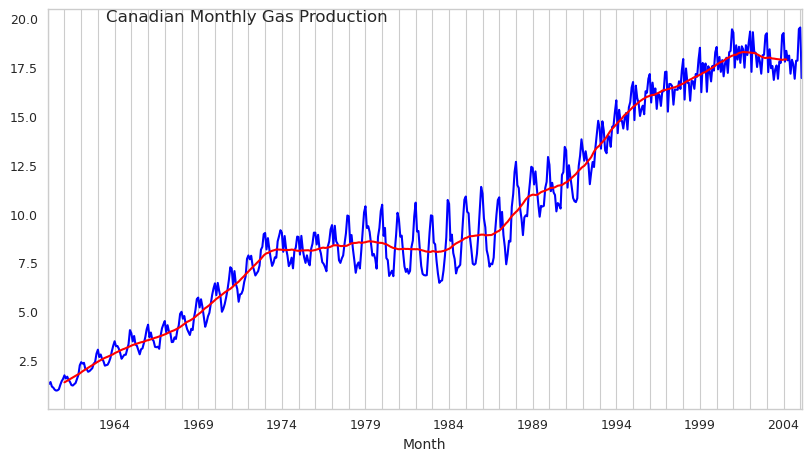

In [80]:
fig, ax = plt.subplots()
can_gas["Volume"].plot(figsize=sizets, c="blue", ax= ax, label="Volume")
can_gas["mean_window_k"].plot(figsize=sizets, c="red", ax= ax, 
label = f"Windowed volumen mean for {window_size} moths")
suptitle('Canadian Monthly Gas Production')
ax.grid(visible=True, which='Both', axis='x')
ax.grid(visible=False, which='Major', axis='y')
plt.show();plt.close()


::: {.callout-tip  icon=false}

### Exercise 004

You can play with the window size and see the effect it has in this plot. What happens with a 5 wide window or an 80 wide one?

Why do you think we picked 24 as the initial value? Which is the *best* choice for window width?

:::

It should be clear that regression methods can play a role in the answer to this question, and there are many possible methods to estimate a trend. 

::: {.callout-tip  icon=false}

### Exercise 005

Apply the above ideas to our `unemployment` dataset, until you are satisfied with the window width. 

:::

---

::: {.callout-note icon=false}

#### Dealing with Seasonality

The seasonal behavior of a time series can often be guessed from expert knowledge of the observed quantity and of the sampling frequency used in the time series. The [table in Section 2.1 of [@hyndman2021fpppy]](https://otexts.com/fpppy/nbs/02-graphics.html#the-seasonal-period) can be used as a guide for the relation between the type of observations (yearly, monthly, weekly, daily, hourly) and the seasonal period that we can expect to find in our data.

:::

For the canadian gas example we have monthly data. Therefore we expect a seasonal period of 12. Let us see if we can confirm it through EDA. We will plot a subseries spanning several years and we will plot a vertical dashed line every twelve months. Ignoring the effect of the trend, can you see the seasonal behavior?

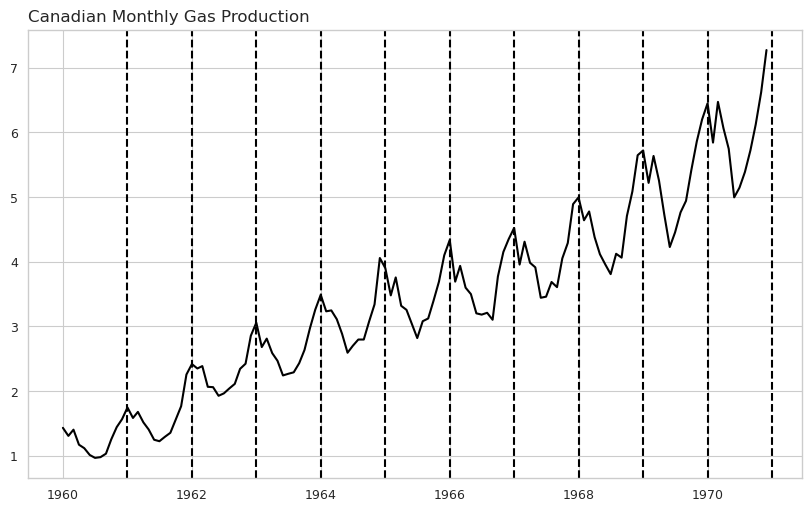

In [81]:
fig, ax = plt.subplots()
num_years = 11
num_months = 12 * num_years
ax.plot(can_gas.index[:num_months], can_gas["Volume"][:num_months], label="Gas Production")

ax.set_title('Canadian Monthly Gas Production')

# Generate vertical dashed lines every 12 months starting from 1961-01-01
xcoords = pd.date_range(start=f"1961-01-01", end=f"1971-01-01", freq='12MS')

# Plot vertical dashed lines
for xc in xcoords:
    ax.axvline(x=xc, color='black', linestyle='--')

plt.show();plt.close()

::: {.callout-tip  icon=false}

### Exercise 006

Uncomment the last line of the cell above to see the dates used for the dashed lines. Now change `freq='12MS'   ` to `freq='12M'` and see the effect in the plot and the dates.

:::

::: {.callout-note icon=false}

#### Seasonal Plots

Once you have a candidate for the seasonal period , the EDA in the previous plot can be organized in a systematic way to obtain the so called **seasonal plots**. In order to plot them we will run an auxiliary code script that contains the plotting functions below.

For that we reindex the `can_gas` dataset to use the month (stored in `ds`) as the temporal index.

:::

In [82]:
can_gas.head()

,Volume,Date,mean_window_k
Month,,,
1960-01-01,1.431,1960 Jan,NaN
1960-02-01,1.306,1960 Feb,NaN
1960-03-01,1.402,1960 Mar,NaN
1960-04-01,1.170,1960 Apr,NaN
1960-05-01,1.116,1960 May,NaN


In [83]:
# can_gas.set_index('ds', drop=True, inplace=True)

In [84]:
%run -i "Time_Series_Graphics.py"

<Figure size 800x500 with 0 Axes>

The first plot stacks the seasonal periods on top of each other so that the trend is reflected in the vertical direction. 

/wd/exclude/MLMIINprv/fc26/4_1_Introduction_to_Forecasting/fc_4_1_utils/utils.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return gb.apply(lambda x: pd.Series(f(x)))


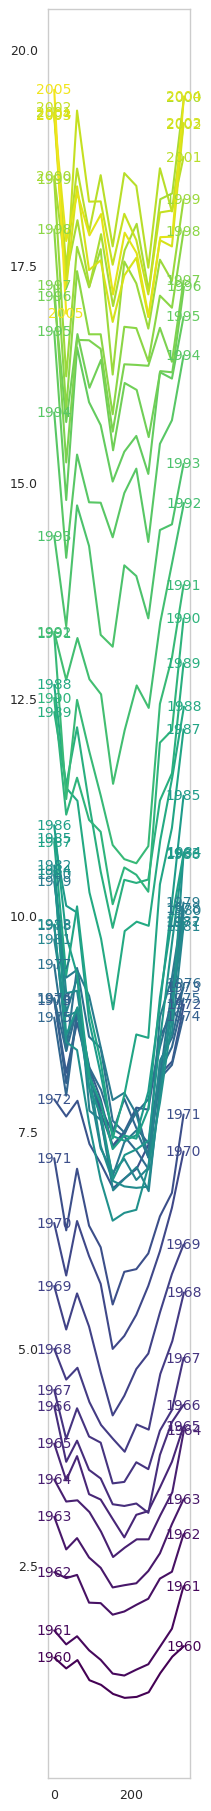

In [85]:
this_fig_size = (2, 18)
ax = plot_seasonal(can_gas, 'Volume', period='Year', labels='both', figsize=this_fig_size)
ax.grid()
plt.show();plt.close()


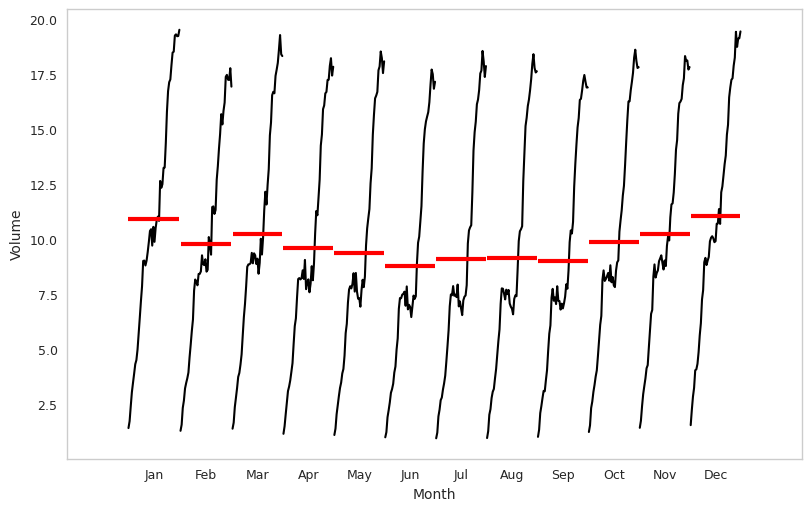

In [86]:
fig, ax = plt.subplots()
sm.graphics.tsa.month_plot(can_gas.Volume, ax=ax)
ax.set(xlabel='Month', ylabel='Volume')
ax.grid()
plt.show();plt.close()

---

::: {.callout-note icon=false}

#### Time Series Additive and Multiplicative Decomposition 

Given a time series $y_t$, an **additive decomposition** is a representation of the series as a sum of terms or **components**. 

$y_{t} = T_{t} + S_{t} +  R_t$

Here 

+ $T_t$ is the **trend term**
+ $S_t$ is the **seasonal term**
+ $R_t$ is called the  **residual** term of the decomposition. It accounts for the remaining behavior of the time series not explained by trend or seasonality. 

Such decompositions are provided by several Python libraries. The one we use here comes from `statsmodels`:

:::

In [87]:
can_gas_decomp_add = seasonal_decompose(can_gas['Volume'], model='additive')

The individual components can be accessed as:

In [88]:
can_gas_decomp_add.trend[0:20]

Month
1960-01-01      NaN
1960-02-01      NaN
1960-03-01      NaN
1960-04-01      NaN
1960-05-01      NaN
1960-06-01      NaN
1960-07-01    1.235
1960-08-01    1.260
1960-09-01    1.283
1960-10-01    1.309
1960-11-01    1.335
1960-12-01    1.357
1961-01-01    1.378
1961-02-01    1.402
1961-03-01    1.428
1961-04-01    1.454
1961-05-01    1.480
1961-06-01    1.523
1961-07-01    1.579
1961-08-01    1.639
Name: trend, dtype: float64

Note the **pure periodicity** in the seasonal component. This is a characteristic of this **classical decomposition**:

In [89]:
can_gas_decomp_add.seasonal[0:24]

Month
1960-01-01    1.202
1960-02-01    0.049
1960-03-01    0.619
1960-04-01   -0.056
1960-05-01   -0.324
1960-06-01   -0.953
1960-07-01   -0.657
1960-08-01   -0.623
1960-09-01   -0.791
1960-10-01    0.043
1960-11-01    0.359
1960-12-01    1.131
1961-01-01    1.202
1961-02-01    0.049
1961-03-01    0.619
1961-04-01   -0.056
1961-05-01   -0.324
1961-06-01   -0.953
1961-07-01   -0.657
1961-08-01   -0.623
1961-09-01   -0.791
1961-10-01    0.043
1961-11-01    0.359
1961-12-01    1.131
Name: seasonal, dtype: float64

And we can get a nice graphical representation of the decomposition as follows:

/opt/conda/envs/mlmiin/lib/python3.11/site-packages/statsmodels/tsa/seasonal.py:360: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


<Figure size 800x500 with 0 Axes>

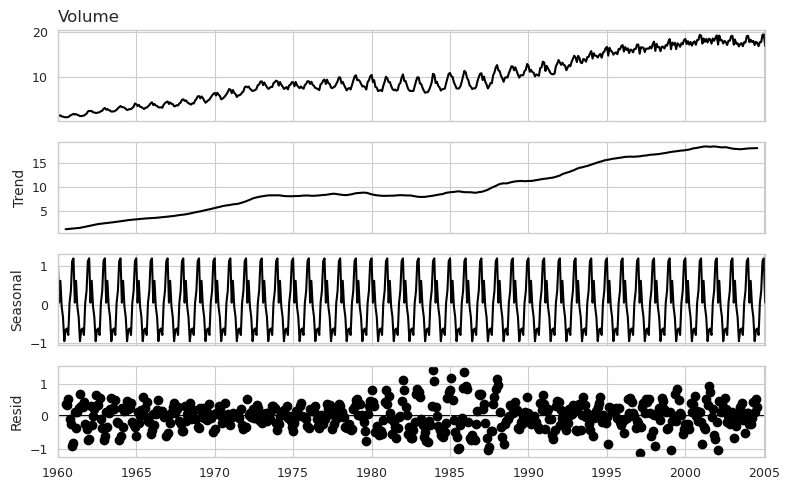

In [90]:
plt.figure()
can_gas_decomp_add.plot()
plt.show();plt.close()

Note here that:
+ the seasonal component is centered at 0. 
+ the vertical axes use a different scale for each component.

::: {.callout-note icon=false}

#### Time Series Multiplicative Decomposition 

An **multiplicative decomposition** is a representation of the series as a **product** of **components**. 

$y_{t} = T_{t} \cdot S_{t} \cdot  R_t$

Where $T_t$, $S_t$ and $R_t$ respectively stand for the **trend, seasonal and residual terms,** with meaning analogous to the additive case.

We can also get multiplicative decompositions from Python libraries, in particular  `statsmodels`:

:::

In [91]:
can_gas_decomp_mult = seasonal_decompose(can_gas['Volume'], model='multiplicative')

And the corresponding visualization is:

/opt/conda/envs/mlmiin/lib/python3.11/site-packages/statsmodels/tsa/seasonal.py:360: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


<Figure size 800x500 with 0 Axes>

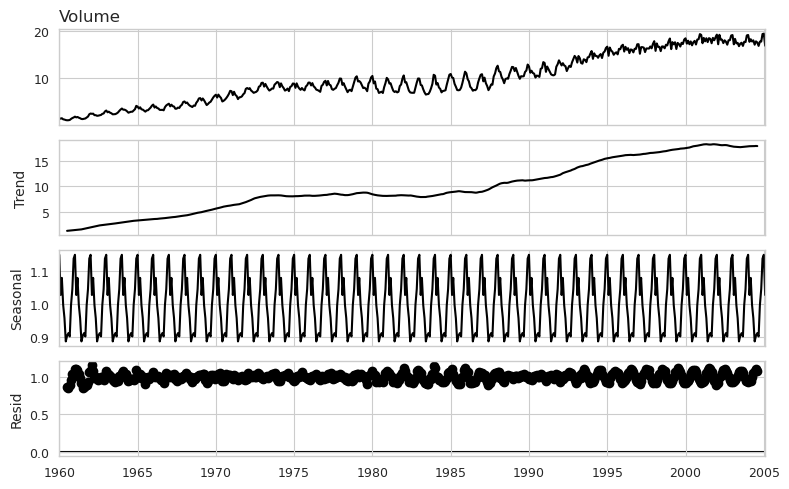

In [92]:
plt.figure()
can_gas_decomp_mult.plot()
plt.show();plt.close()

Note that the residual and seasonal components are centered in 1 now, instead of zero.

::: {.callout-note icon=false}

#### Additive vs Multiplicative

When do we use a multiplicative decomposition and when is it better to use an additive one? Multiplicative decompositions are typical of economical or financial time series, in which the amplitude of the seasonal component is not constant. This kind of behavior is present in the canadian gas example, but is much more noticeable in the `a10` example (remember, a time series of budget costs of antidiabetic drugs in Australia). 

:::

In [93]:
a10_decomp_mult = seasonal_decompose(a10, model='multiplicative')

/opt/conda/envs/mlmiin/lib/python3.11/site-packages/statsmodels/tsa/seasonal.py:360: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


<Figure size 800x500 with 0 Axes>

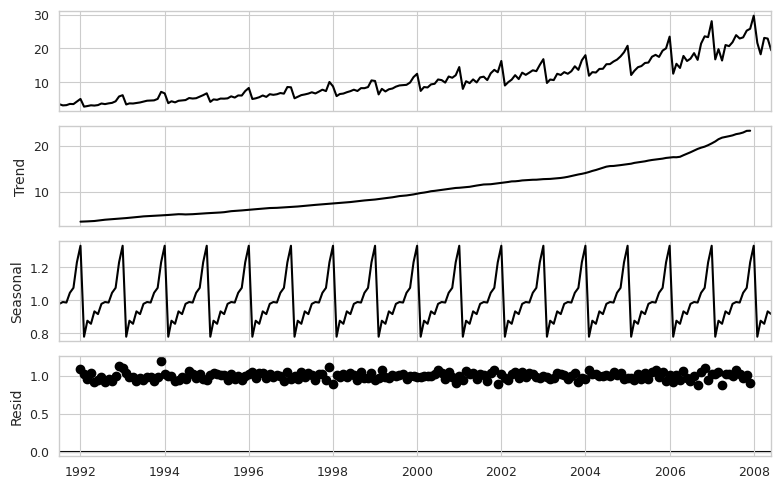

In [94]:
plt.figure()
a10_decomp_mult.plot()
plt.show();plt.close()

## Decomposition in Nixtla, modern methods

+ Classical decomposition has some drawbacks, such as assuming perfectly periodic seasonal component (and a single seasonality). Many other methods to address the decomposition problem have been developed. Some of these methods are of particular importance, as government agencies and institutions are often tasked to determine statistics for their regulatory use or to inform public policies (e.g. some consumer price index is often used to decide on salary, pensions, house rents, etc.) Classical decomposition is too simple to account for the demands of this kind of problems. You can get further information about this in [Section 3.5 of @@hyndman2025fpppy](https://otexts.com/fpppy/nbs/03-decomposition.html#methods-used-by-official-statistics-agencies). However, these *official methods* need to be stable, and therefore more advanced decomposition methods have continued to evolve to provide better decompositions, such as the [MSTL method (Multiple Seasonal-Trend decomposition using LOESS)](https://nixtlaverse.nixtla.io/statsforecast/docs/models/multipleseasonaltrend.html). 

+ Compared with classical decomposition, recent methods such as MSTL or Prophet offer more flexibility by being able to capture multiple seasonalities, allowing them to evolve in time, deal with outliers robustly and also provide more advanced trend estimation methods than the classical moving average. 

+ Some of these methods are provided in the Nixtlaverse, so let us see how they apply to one of our examples. 




In [171]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL
horizon = 12 # number of predictions


We create an instance of the MSTL model class.

In [ ]:
models = [MSTL(season_length=[12])]
mstl_can_gas = StatsForecast(models=models, freq='m')

And we fit it:

In [174]:
mstl_can_gas.fit(df=can_gas_nx)

StatsForecast(models=[MSTL])

Now we can access the decomposition data frame as follows:

In [ ]:
can_cas_stl_comp = mstl_can_gas.fitted_[0,0].model_
can_cas_stl_comp

,data,trend,seasonal,remainder
0,1.431,1.078,0.527,-0.175
1,1.306,1.105,0.221,-0.021
2,1.402,1.132,0.313,-0.042
3,1.170,1.157,0.020,-0.007
4,1.116,1.182,-0.113,0.047
...,...,...,...,...
537,17.827,17.975,0.069,-0.218
538,17.832,17.972,-0.068,-0.072
539,19.453,17.969,1.027,0.457
540,19.528,17.967,1.225,0.336


Let us plot each component of the STL decomposition in a separate subplot

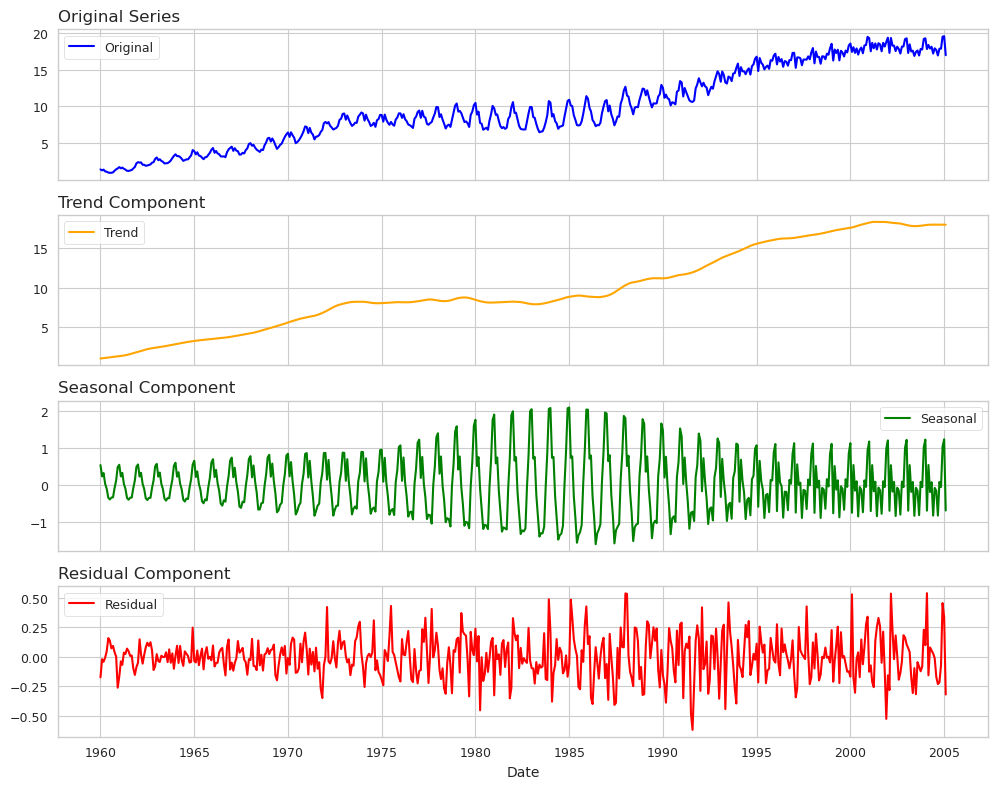

In [191]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
axes[0].plot(can_gas_nx['ds'], can_gas_nx['y'], label='Original', color='blue')
axes[0].set_title('Original Series')
axes[0].legend()    
axes[1].plot(can_gas_nx['ds'], can_cas_stl_comp.trend, label='Trend', color='orange')
axes[1].set_title('Trend Component')
axes[1].legend()            
axes[2].plot(can_gas_nx['ds'], can_cas_stl_comp.seasonal, label='Seasonal', color='green')
axes[2].set_title('Seasonal Component')
axes[2].legend()
axes[3].plot(can_gas_nx['ds'], can_cas_stl_comp.remainder, label='Residual', color='red')
axes[3].set_title('Residual Component')
axes[3].legend()
plt.xlabel('Date')
plt.tight_layout()
plt.show();plt.close()


The nice thing about this being a model is that we can use it to make predictions:

In [193]:
mstl_can_gas_forecast = mstl_can_gas.forecast(df=can_gas_nx, h=horizon, fitted=True, level=[80, 95])
mstl_can_gas_forecast

,unique_id,ds,MSTL,MSTL-lo-95,MSTL-lo-80,MSTL-hi-80,MSTL-hi-95
0,Canadian gas production,2005-02-28,18.462,18.036,18.184,18.741,18.888
1,Canadian gas production,2005-03-31,17.739,17.248,17.418,18.059,18.229
2,Canadian gas production,2005-04-30,18.014,17.464,17.654,18.374,18.565
3,Canadian gas production,2005-05-31,17.118,16.511,16.721,17.514,17.724
4,Canadian gas production,2005-06-30,17.877,17.217,17.445,18.309,18.537
5,Canadian gas production,2005-07-31,17.808,17.096,17.343,18.274,18.520
6,Canadian gas production,2005-08-31,17.145,16.383,16.647,17.644,17.908
7,Canadian gas production,2005-09-30,18.062,17.251,17.532,18.593,18.874
8,Canadian gas production,2005-10-31,17.934,17.074,17.371,18.496,18.794
9,Canadian gas production,2005-11-30,19.037,18.129,18.443,19.631,19.945


In [189]:
mstl_can_gas_forecast = mstl_can_gas.predict(h=horizon, level=[80,95])
# forecast_df = mstl_can_gas.forecast_fitted_values()
mstl_can_gas_forecast

,unique_id,ds,MSTL,MSTL-lo-95,MSTL-lo-80,MSTL-hi-80,MSTL-hi-95
0,Canadian gas production,2005-02-28,18.462,18.036,18.184,18.741,18.888
1,Canadian gas production,2005-03-31,17.739,17.248,17.418,18.059,18.229
2,Canadian gas production,2005-04-30,18.014,17.464,17.654,18.374,18.565
3,Canadian gas production,2005-05-31,17.118,16.511,16.721,17.514,17.724
4,Canadian gas production,2005-06-30,17.877,17.217,17.445,18.309,18.537
5,Canadian gas production,2005-07-31,17.808,17.096,17.343,18.274,18.520
6,Canadian gas production,2005-08-31,17.145,16.383,16.647,17.644,17.908
7,Canadian gas production,2005-09-30,18.062,17.251,17.532,18.593,18.874
8,Canadian gas production,2005-10-31,17.934,17.074,17.371,18.496,18.794
9,Canadian gas production,2005-11-30,19.037,18.129,18.443,19.631,19.945


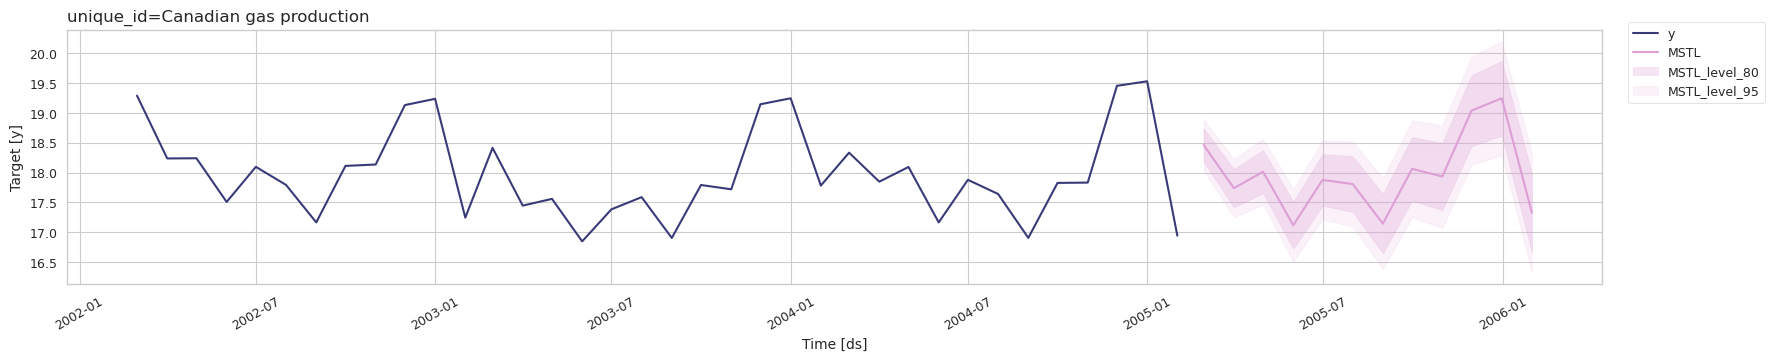

In [194]:
mstl_can_gas.plot(can_gas_nx.tail(36), mstl_can_gas_forecast, level=[80, 95])

Or directly:

In [128]:
mstl_model.predict(h = 12)

{'mean': array([18.46221207, 17.7385221 , 18.01432268, 17.11750586, 17.87693151,
        17.80824766, 17.14516461, 18.06244827, 17.93383104, 19.03709127,
        19.24397917, 17.32624562])}

Strength of the seasonal and trend component (see fpppy Chapter 4)

In [100]:
import tsfeatures as tsf
can_cas_featrs = tsf.tsfeatures(can_gas_nx, freq=12, features=[tsf.stl_features])
can_cas_featrs.head()

,unique_id,nperiods,seasonal_period,trend,spike,linearity,curvature,e_acf1,e_acf10,seasonal_strength,peak,trough
0,Canadian gas production,1,12,0.999,1.450e-11,22.382,1.919,0.197,0.14,0.949,1,6


---

::: {.callout-note  icon=false}

## In the Next Session

We will discuss time series in the wider context of stochastic processes and we will meet out first forecasting models. 

:::

# References